In [1]:
print("OK")

OK


In [114]:
from langchain_openai import ChatOpenAI

In [244]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [241]:
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")

In [118]:
os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY

In [119]:
openai_model=ChatOpenAI(model="gpt-4o")

In [120]:
openai_model.invoke("What is the capital of France?").content

'The capital of France is Paris.'

In [121]:
from langgraph.graph import StateGraph, START, END

In [122]:
from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

In [123]:
state={}

In [124]:
state["messages"]=[]

In [125]:
def call_model(state:MessagesState):
    question=state["messages"]
    response=openai_model.invoke(question)
    return {"messages":[response]}

In [126]:
workflow=StateGraph(MessagesState)

In [127]:
workflow.add_node("chatbot",call_model)

In [128]:
workflow.add_edge(START,"chatbot")

In [129]:
workflow.add_edge("chatbot",END)

In [130]:
app=workflow.compile()

In [131]:
from IPython.display import Image,display

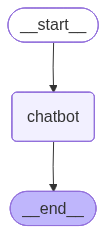

In [132]:
display(Image(app.get_graph().draw_mermaid_png()))

In [133]:
input={"messages":["hi my name is sambit"]}

In [134]:
response=app.invoke(input)

In [135]:
response["messages"][-1].content

'Hello Sambit! How can I assist you today?'

In [136]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from chatbot Node
_______
{'messages': [AIMessage(content='Hello Sambit! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 13, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_c5713eb5e1', 'id': 'chatcmpl-DfNDsRyeR2qk98UxUV6aWMdjbMD9Y', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e25f2-2055-7290-992a-8f4b29c1ad32-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 11, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}




In [137]:
@tool
def search(query:str):
    """this is a tool for weather checking"""
    if "india" in query.lower() or "delhi" in query.lower():
        return "the weather is hot with some fog"
    return "weather is cloudy with some darkness"

In [138]:
search.invoke("what is a weather in japan?")

'weather is cloudy with some darkness'

In [139]:
search.invoke("what is a weather in delhi?")

'the weather is hot with some fog'

In [140]:
tools=[search]

In [141]:
llm_with_tool=openai_model.bind_tools(tools)

In [142]:
response=llm_with_tool.invoke("hi")

In [143]:
response.content

'Hello! How can I assist you today?'

In [144]:
response.tool_calls

[]

In [145]:
result=llm_with_tool.invoke("what is a weather in europe?")

In [146]:
result.content

''

In [36]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'weather in Europe'},
  'id': 'call_G7LP34s0cPhZPVW7y3gB2wzC',
  'type': 'tool_call'}]

In [147]:
def call_model(state:MessagesState):
    question=state["messages"]
    response=llm_with_tool.invoke(question)
    return {"messages":[response]}

In [148]:
input={'messages': ['hi my name is sambit']}

In [149]:
response=call_model(input)

In [150]:
message=response["messages"]

In [151]:
last_message=message[-1]

In [152]:
last_message.content

'Hello Sambit! How can I assist you today?'

In [43]:
last_message.tool_calls

[]

In [153]:
input={'messages': ['what is a weather in mumbai?']}

In [154]:
def router_function(state: MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [155]:
tools

[StructuredTool(name='search', description='this is a tool for weather checking', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000017CFCF1C2C0>)]

In [156]:
tool_node=ToolNode(tools)

In [157]:

workflow=StateGraph(MessagesState)

In [158]:
workflow.add_node("assistant",call_model)
workflow.add_node("myweathertool",tool_node)

In [159]:
workflow.add_edge(START, "assistant")

workflow.add_conditional_edges("assistant",
                               router_function,
                               {"tools": "myweathertool", END: END})

app = workflow.compile()

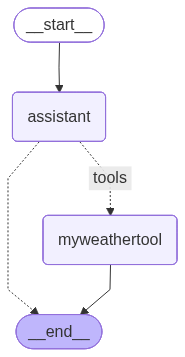

In [160]:
display(Image(app.get_graph().draw_mermaid_png()))

In [161]:
app.invoke({"messages": ["how are you?"]})

{'messages': [HumanMessage(content='how are you?', additional_kwargs={}, response_metadata={}, id='f9e6d8ed-3c35-44fd-9b80-b2c081ff94b8'),
  AIMessage(content="I'm just a computer program, so I don't have feelings, but I'm here and ready to assist you! How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 48, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfNEcbja0wmvEoxkZ9E7N2BcraeKl', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e25f2-dd29-75a2-bc70-ef7db2c0f37e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 29, 'total

In [162]:
app.invoke({"messages": ["what is a weather in bhubaneswar?"]})

{'messages': [HumanMessage(content='what is a weather in bhubaneswar?', additional_kwargs={}, response_metadata={}, id='d023cb6d-ce88-4e7e-8a37-19b66e1c1b6f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 54, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfNEdvjdMHKcFYAgQj2bHPDIGEGM9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e25f2-e352-7b52-aa7e-e5657c622160-0', tool_calls=[{'name': 'search', 'args': {'query': 'Bhubaneswar weather'}, 'id': 'call_igjIkDgWuGDNkXtuyuAflPwp', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54

In [163]:
workflow.add_edge("myweathertool","assistant")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [164]:
app = workflow.compile()

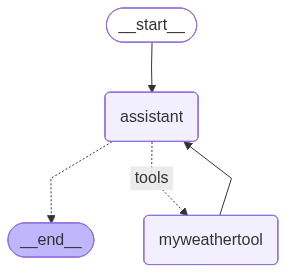

In [165]:
display(Image(app.get_graph().draw_mermaid_png()))

In [166]:
app.invoke({"messages": ["what is a weather in Bhubaneswar?"]})

{'messages': [HumanMessage(content='what is a weather in Bhubaneswar?', additional_kwargs={}, response_metadata={}, id='6186aaea-90a4-4a4f-9abc-86821152f1da'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 54, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfNEjzNbpgAMd6yIvCNXWXPJSWl44', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e25f2-fc71-7031-aab7-c7722954eed7-0', tool_calls=[{'name': 'search', 'args': {'query': 'Bhubaneswar weather'}, 'id': 'call_OfLikCAspQdu22nPyXuhI4Lk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 54

In [167]:
for output in app.stream({"messages": ["what is the weather in Bhubaneswar"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from assistant
_______
{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 53, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfNEniYrOCjCCuhG0UsSmUyMkgzzl', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e25f3-0446-7cc1-bb05-4da9f2c60a0c-0', tool_calls=[{'name': 'search', 'args': {'query': 'Bhubaneswar weather'}, 'id': 'call_Z5p6Q6YWOLo7gXUW7meQNgai', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 53, 'output_tokens': 17, 'total_tokens': 70, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

In [168]:
@tool
def multiply(a:int,b:int)->int:
    """multiply a and b"""
    return a*b

In [169]:
@tool
def add(a:int,b:int)->int:
    """adding two numbers a and b"""
    return a+b

In [170]:
@tool
def divide(a:int,b:int)->int:
    """dividing two numbers a and b"""
    return a/b

In [171]:
@tool
def subtract(a:int,b:int)->int:
    """subtracting two numbers a and b """
    return a-b

In [172]:
from langchain_community.tools import DuckDuckGoSearchRun

In [173]:
duckduckgo_search=DuckDuckGoSearchRun()

In [174]:
duckduckgo_search.invoke("who is a current prime minister of India??")

"Narendra Damodardas Modi[a] (born 17 September 1950) is an Indian politician who has served as the prime minister of India since 2014. Modi was the chief minister of Gujarat from 2001 to 2014 and is the member of parliament (MP) for Varanasi. 4 days ago · Shri Narendra Modi was sworn-in as India’s Prime Minister for the third time on 9th June 2024, following another decisive victory in the 2024 Parliamentary elections. This victory marked the third consecutive term for Shri Modi, further solidifying his leadership. Narendra Modi, the 14th Prime Minister of India, is a figure whose political journey is as intriguing as inspiring. Rising from humble beginnings, Modi's ascent through the ranks of the Rashtriya Swayamsevak Sangh (… Feb 17, 2026 · Currently, Narendra Modi is the Prime Minister of India, having been in office since 2014. He is the 14th Prime Minister of India who had three consecutive terms on the post. 1 day ago · Shri Narendra Modi was sworn-in as India’s Prime Minister f

In [175]:
tools=[multiply, add, divide, subtract, duckduckgo_search]

In [176]:
llm_with_tools=openai_model.bind_tools(tools)

In [177]:
llm_with_tools.invoke("hi").tool_calls

[]

In [178]:
llm_with_tools.invoke("can you add these two number 5 and 40?").tool_calls

[{'name': 'add',
  'args': {'a': 5, 'b': 40},
  'id': 'call_VNErDVvU4AjXCAGFfiyrqAi0',
  'type': 'tool_call'}]

In [179]:
llm_with_tools.invoke("what is a current gdp of india with current affaires").tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'current GDP of India 2023'},
  'id': 'call_0Bjdr9z5pLvdmSXIbHgT3DlK',
  'type': 'tool_call'}]

In [180]:
from langchain_core.messages import HumanMessage, SystemMessage

In [181]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [182]:
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg]+state["messages"])]}

In [183]:
builder=StateGraph(MessagesState)

In [184]:
builder.add_node("assistant",assistant)

In [185]:
builder.add_node("tools",ToolNode(tools))

In [186]:
builder.add_edge(START,"assistant")

In [187]:
from langgraph.prebuilt import tools_condition

In [188]:
builder.add_conditional_edges(
    "assistant",
    tools_condition
)

In [189]:
react_app=builder.compile()

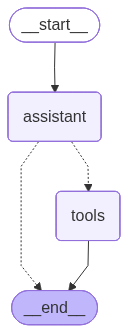

In [190]:
display(Image(react_app.get_graph().draw_mermaid_png()))

In [191]:
builder.add_edge("tools","assistant")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [192]:
react_app=builder.compile()

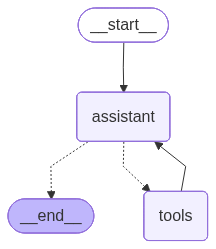

In [193]:
display(Image(react_app.get_graph().draw_mermaid_png()))

In [194]:
message=[HumanMessage(content="what is twice of narendra modi's age in 2026?")]
## this below detail is called a agentic flow
# first it will come to assistant
# then it will search narendra modi age
# then it will come to again assistant
# then it wil call the multiply tool for getting twice of age
# then again it will come to assistant 
# then it will generate a final answer

# REACT->> Reasoning+actions

# Thinking, action, observation, thiniking,action, observation---> if everything is going to be full fill
# then generating a final ans

In [195]:
response=react_app.invoke({"messages":message})

In [196]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is twice of narendra modi's age in 2026?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_1eobsRC3bSvRVzqL2WPttKRv)
 Call ID: call_1eobsRC3bSvRVzqL2WPttKRv
  Args:
    query: Narendra Modi age 2026
================================= Tool Message =================================
Name: duckduckgo_search

List of all Prime Ministers of India till 2026: Narendra Modi is the current and 14th Prime Minister of India, who assumed office on 10 June 2024. Narendra Modi age 2026 revealed! Know his height, weight, fitness routine, diet plan & full biography. Read complete details and facts here. Narendra Modi is the 14th prime minister of India. His Hindu nationalist policies and some of his economic reforms have proved controversial to many within and outside India. Indian prime minister Narendra Modi celebrates his 75th birthday today, an a

In [ ]:
## Building new agent

In [197]:
## MultiAgent

In [201]:
from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage,BaseMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
import operator,json
from typing_extensions import Annotated, TypedDict, Sequence
from langchain_community.tools.tavily_search import TavilySearchResults


In [269]:
@tool
def multiply(first_number:int, second_number:int)->int:
    """multiply two integer number"""
    return first_number * second_number

In [271]:
@tool
def search(query:str):
    """perform the web search on the user query"""
    tavily=TavilySearchResults(tavily_api_key="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")
    result=tavily.invoke(query)
    return result

In [272]:
search.invoke("who is the Grigory Perelman?")

[{'title': 'Grigory Perelman（Russian mathematician）_Baiduwiki',
  'url': 'https://baike.baidu.com/en/item/Grigory%20Perelman/1523448',
  'content': "00:59\n\nGrigory Perelman (Grigory Perelman), born on June 13, 1966, in Leningrad, Union of Soviet Socialist Republics (now Saint Petersburg), is a Russia mathematician. He graduated from Saint Petersburg University and the Steklov Institute of Mathematics of the Russian Academy of Sciences, specializing in differential geometry and Ricci flow theory. He is renowned for proving the Poincaré conjecture . His mother was a mathematics teacher, and his father was an electronics engineer. He received professional mathematical training from a young age. [...] One of the 2006 Fields Medal laureates, Russian mathematician Grigory Perelman, is a mysterious figure. Shortly after publishing three key papers on the Poincaré conjecture on the Internet, Perelman disappeared from public view, and even the Fields Medal likely could not draw him out.\n\nIn

In [273]:
tools= [search, multiply]

In [274]:
model_with_tools=openai_model.bind_tools(tools)

In [276]:
model_with_tools.invoke("who is a cuurent pm of japan?").tool_calls

[{'name': 'search',
  'args': {'query': 'current Prime Minister of Japan 2023'},
  'id': 'call_lDEH3gDvqFCxMneTsmOWPxhI',
  'type': 'tool_call'}]

In [277]:
tool_mapping={tool.name: tool for tool in tools}

In [279]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage], operator.add]

In [280]:
def invoke_model(state:AgentState):
    messages = state['messages']
    question = messages[-1]   ## Fetching the user question
    return {"messages":[model_with_tools.invoke(question)]}

In [281]:
def invoke_tool(state:AgentState):
    print("****my state*****")
    print(state['messages'][-1])
    tool_details= state['messages'][-1].additional_kwargs.get("tool_calls", [])[0]
    
    if tool_details is None:
        raise Exception("no tool call found")
    
    print(f'Selected tool: {tool_details.get("function").get("name")}')
    
    if tool_details.get("function").get("name")=="search":
        print("**********tool detils****")
        print(tool_details)
        response = input(prompt=f"[y/n] continue with expensive web search?")
        if response == "n":
            raise Exception("web search discard")
        
    response = tool_mapping[tool_details['function']['name']].invoke(json.loads(tool_details.get("function").get("arguments")))
    return {"messages" : [response]}

In [282]:
def router(state:AgentState):
    tool_calls = state['messages'][-1].additional_kwargs.get("tool_calls", [])
    if len(tool_calls):
        return "tool"
    else:
        return "end"
     

In [293]:
graph=StateGraph(AgentState)  

In [294]:
graph.add_node("ai_assistant",invoke_model)
graph.add_node("tool",invoke_tool)


In [295]:
graph.add_conditional_edges("ai_assistant",
                            router,
                            {"tool":"tool",
                             "end":END})

In [296]:
graph.add_edge("tool", END)

graph.add_edge("tool", "ai_assistant")

graph.set_entry_point("ai_assistant")

In [297]:
app=graph.compile()

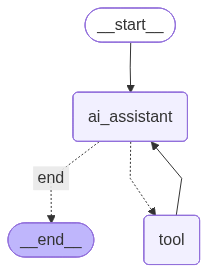

In [298]:
display(Image(app.get_graph().draw_mermaid_png()))

In [299]:
app.invoke({"messages": ["who is thepresident of USA?"]})

{'messages': ['who is thepresident of USA?',
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_50ff68eacb', 'id': 'chatcmpl-DfRAggbDK1Hc5QiiKSW3K3koDFALH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e26d9-c54a-7ad1-9fef-ff5fced86cf5-0', tool_calls=[{'name': 'search', 'args': {'query': 'current President of the USA'}, 'id': 'call_vWJUSrTRdtnMWEBI79FHKJhX', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 17, 'total_tokens': 94, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_t

In [267]:
for s in app.stream({"messages": ["who is upcoming president of USA?"]}):
    print(list(s.values())[0])
    print("----")

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 74, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfQwMl1PindIVxo30nydoEkQ2s9Im', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e26cc-37f4-77a3-a6da-792f7064e3ea-0', tool_calls=[{'name': 'search', 'args': {'query': 'upcoming president of USA 2024'}, 'id': 'call_iRkH9yjzmC17NP8APUf5HWCu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 20, 'total_tokens': 94, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 're

In [268]:
app.invoke({"messages": ["what is multiplication of 23 and 46?"]})

{'messages': ['what is multiplication of 23 and 46?',
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 77, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fdcd217abe', 'id': 'chatcmpl-DfQwcOExpVri8cuuMj7dm4tJCHIQv', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e26cc-728a-70f1-a7ad-470a2eeb7d47-0', tool_calls=[{'name': 'multiply', 'args': {'a': 23, 'b': 46}, 'id': 'call_lsJJUiJ3H2jJjAjSIV01Hdmi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 17, 'total_tokens': 94, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details